# Рубежный контроль №1

**Дисциплина:** Интеллектуальный анализ данных / технологии разведочного анализа и обработки данных  
**Тема:** Обработка пропусков в данных и сравнение исходного и итогового наборов данных  
**Студент:** Качалов Глеб Владимирович
**Группа:** ИБМ3-65Б

В работе используется набор данных `Iris` из библиотеки `scikit-learn`. Для выполнения задания были искусственно добавлены категориальные признаки и пропуски, после чего выполнена обработка пропусков:

- для **количественных признаков** применяется метод **MICE** (`IterativeImputer`);
- для **категориальных признаков** используется заполнение **наиболее частым значением** (`most_frequent`), после чего выполняется **Ordinal Encoding**.

Дополнительно в отчете построена **гистограмма** для одного из признаков и выполнено **сравнение начального и итогового датасетов**.

In [2]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 1. Загрузка данных

Используются два подготовленных файла:

- `data/iris2.csv` - начальный датасет после добавления категориальных признаков;
- `data/iris_with_nan.csv` - тот же датасет, но уже с искусственно внесенными пропусками.

In [3]:
df_initial = pd.read_csv('data/iris2.csv')
df_with_nan = pd.read_csv('data/iris_with_nan.csv')

print('Размер начального датасета:', df_initial.shape)
print('Размер датасета с пропусками:', df_with_nan.shape)

display(df_initial.head())
display(df_with_nan.head())

Размер начального датасета: (150, 7)
Размер датасета с пропусками: (150, 7)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_length_cat,sepal_width_cat
0,5.100,3.500,1.400,0.200,0,small,medium
1,4.900,3.000,1.400,0.200,0,small,medium
2,4.700,3.200,1.300,0.200,0,small,medium
3,4.600,3.100,1.500,0.200,0,small,medium
4,5.000,3.600,1.400,0.200,0,small,medium


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_length_cat,sepal_width_cat
0,5.100,3.500,1.400,0.200,NaN,NaN,NaN
1,4.900,3.000,1.400,NaN,0.000,small,medium
2,NaN,NaN,1.300,0.200,0.000,small,medium
3,NaN,3.100,1.500,0.200,0.000,NaN,medium
4,5.000,NaN,1.400,NaN,NaN,small,medium


## 2. Анализ пропусков

Проверим, в каких столбцах появились пропуски. Это позволит убедиться, что задача обработки пропущенных значений действительно актуальна как для числовых, так и для категориальных признаков.

In [4]:
missing_table = pd.DataFrame({
    'Количество пропусков': df_with_nan.isna().sum(),
    'Доля пропусков, %': (df_with_nan.isna().mean() * 100).round(2)
})

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
sepal length (cm),34,22.670
sepal width (cm),34,22.670
petal length (cm),29,19.330
petal width (cm),41,27.330
target,31,20.670
petal_length_cat,31,20.670
sepal_width_cat,35,23.330


## 3. Обработка пропусков

В соответствии с условием задачи:

- для **количественных признаков** используется метод **MICE** (`IterativeImputer`);
- для **категориальных признаков** используется заполнение наиболее частым значением.

После восстановления категориальные признаки кодируются с помощью `OrdinalEncoder`, так как категории имеют естественный порядок: `small < medium < large`.

In [5]:
df_work = df_with_nan.copy()

num_cols = df_work.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_work.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

print('Числовые признаки:', num_cols)
print('Категориальные признаки:', cat_cols)

# Восстановление числовых признаков методом MICE
num_imputer = IterativeImputer(max_iter=10, random_state=42)
df_num_imputed = pd.DataFrame(
    num_imputer.fit_transform(df_work[num_cols]),
    columns=num_cols
)

# Восстановление категориальных признаков наиболее частым значением
cat_imputer = SimpleImputer(strategy='most_frequent')
df_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(df_work[cat_cols]),
    columns=cat_cols
)

# Кодирование категориальных признаков
category_order = ['small', 'medium', 'large']
encoder = OrdinalEncoder(categories=[category_order] * len(cat_cols))
df_cat_encoded = pd.DataFrame(
    encoder.fit_transform(df_cat_imputed),
    columns=cat_cols
)

df_final = pd.concat([df_num_imputed, df_cat_encoded], axis=1)

print('Проверка пропусков после обработки:')
display(df_final.isna().sum())
display(df_final.head())

Числовые признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
Категориальные признаки: ['petal_length_cat', 'sepal_width_cat']
Проверка пропусков после обработки:


C:\Users\Татьяна\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
petal_length_cat     0
sepal_width_cat      0
dtype: int64

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_length_cat,sepal_width_cat
0,5.100,3.500,1.400,0.200,-0.085,1.000,1.000
1,4.900,3.000,1.400,0.083,0.000,0.000,1.000
2,4.812,3.320,1.300,0.200,0.000,0.000,1.000
3,4.798,3.100,1.500,0.200,0.000,1.000,1.000
4,5.000,3.389,1.400,0.202,-0.065,0.000,1.000


## 4. Гистограмма

Для выполнения дополнительного требования построим гистограмму для количественного признака **`sepal length (cm)`**. На графике показано распределение этого признака в итоговом датасете после обработки пропусков.

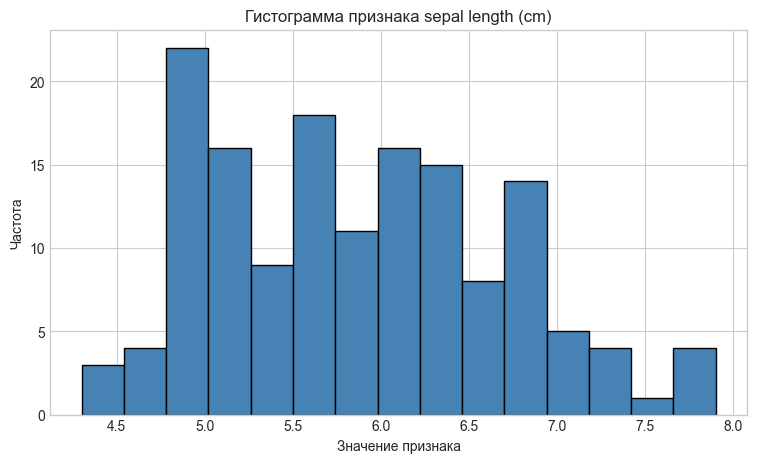

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(df_final['sepal length (cm)'], bins=15, color='steelblue', edgecolor='black')
plt.title('Гистограмма признака sepal length (cm)')
plt.xlabel('Значение признака')
plt.ylabel('Частота')
plt.show()

## 5. Сравнение начального и итогового датасетов

Сравним начальный датасет `df_initial` и итоговый датасет `df_final`:

- изменилось ли число пропусков;
- как изменились типы признаков;
- насколько отличаются числовые характеристики;
- как изменились категориальные признаки после кодирования.

In [7]:
comparison_general = pd.DataFrame({
    'Начальный датасет': [df_initial.shape[0], df_initial.shape[1], int(df_initial.isna().sum().sum())],
    'Итоговый датасет': [df_final.shape[0], df_final.shape[1], int(df_final.isna().sum().sum())]
}, index=['Количество строк', 'Количество столбцов', 'Общее число пропусков'])

display(comparison_general)

dtype_comparison = pd.DataFrame({
    'Тип в начальном датасете': df_initial.dtypes.astype(str),
    'Тип в итоговом датасете': df_final.dtypes.astype(str)
})

display(dtype_comparison)

,Начальный датасет,Итоговый датасет
Количество строк,150,150
Количество столбцов,7,7
Общее число пропусков,0,0


,Тип в начальном датасете,Тип в итоговом датасете
sepal length (cm),float64,float64
sepal width (cm),float64,float64
petal length (cm),float64,float64
petal width (cm),float64,float64
target,int64,float64
petal_length_cat,str,float64
sepal_width_cat,str,float64


In [8]:
numeric_compare = pd.DataFrame({
    'Среднее (начальный)': df_initial[num_cols].mean(),
    'Среднее (итоговый)': df_final[num_cols].mean(),
    'Абс. разница средних': (df_final[num_cols].mean() - df_initial[num_cols].mean()).abs()
}).round(4)

display(numeric_compare)

cat_before = df_initial[cat_cols].apply(lambda col: col.value_counts(dropna=False).to_dict())
cat_after = df_cat_encoded[cat_cols].apply(lambda col: col.value_counts(dropna=False).to_dict())

cat_compare = pd.DataFrame({
    'Распределение до обработки': cat_before,
    'Распределение после обработки и кодирования': cat_after
})

display(cat_compare)

,Среднее (начальный),Среднее (итоговый),Абс. разница средних
sepal length (cm),5.843,5.853,0.009
sepal width (cm),3.057,3.067,0.010
petal length (cm),3.758,3.740,0.018
petal width (cm),1.199,1.194,0.005
target,1.000,1.006,0.006


,Распределение до обработки,Распределение после обработки и кодирования
petal_length_cat,"{'medium': 58, 'small': 50, 'large': 42}","{1.0: 81, 0.0: 37, 2.0: 32}"
sepal_width_cat,"{'medium': 131, 'small': 19}","{1.0: 133, 0.0: 17}"


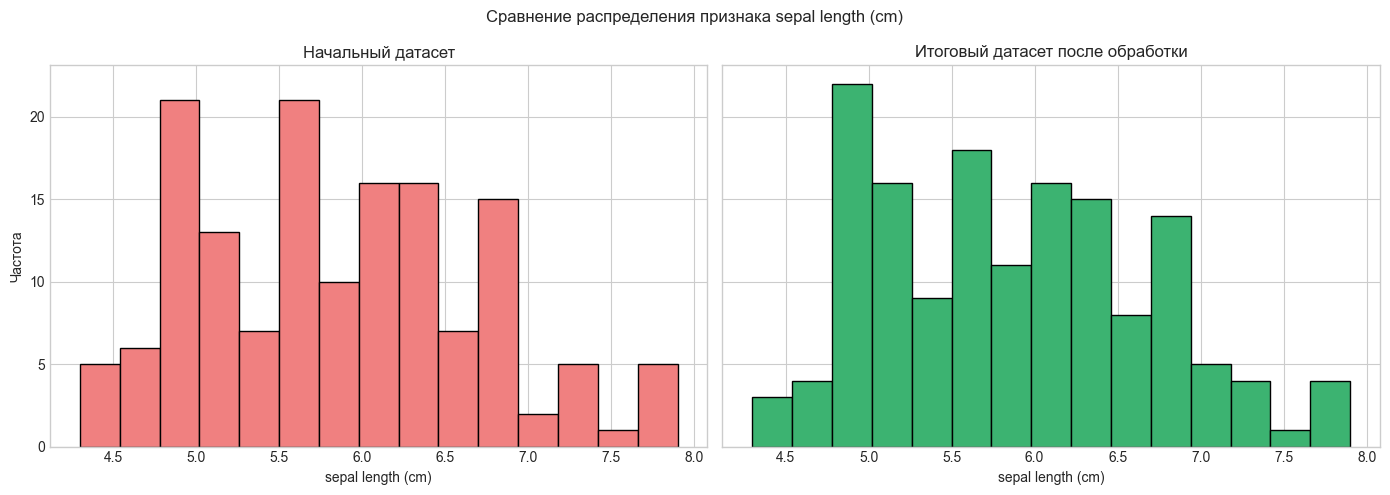

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(df_initial['sepal length (cm)'], bins=15, color='lightcoral', edgecolor='black')
axes[0].set_title('Начальный датасет')
axes[0].set_xlabel('sepal length (cm)')
axes[0].set_ylabel('Частота')

axes[1].hist(df_final['sepal length (cm)'], bins=15, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Итоговый датасет после обработки')
axes[1].set_xlabel('sepal length (cm)')

plt.suptitle('Сравнение распределения признака sepal length (cm)')
plt.tight_layout()
plt.show()

## 6. Выводы

1. Для **категориальных признаков** использовалось заполнение **наиболее частым значением** (`most_frequent`), так как этот способ хорошо подходит для небольшого числа категорий и позволяет сохранить наиболее типичное значение признака.
2. Для **количественных признаков** применялся метод **MICE** (`IterativeImputer`), поскольку он восстанавливает значения с учетом взаимосвязей между признаками и обычно дает более реалистичный результат, чем простая подстановка среднего или медианы.
3. После обработки в итоговом датасете **не осталось пропусков**, а категориальные признаки были дополнительно преобразованы в числовой вид для дальнейшего использования в моделях машинного обучения.
4. Начальный и итоговый датасеты имеют одинаковое число строк и столбцов, однако отличаются по содержанию:
   - в итоговом датасете отсутствуют пропуски;
   - категориальные признаки закодированы числами;
   - числовые характеристики немного изменились из-за восстановления пропущенных значений методом MICE.
5. Для дальнейшего построения моделей машинного обучения целесообразно использовать **все числовые признаки исходного набора Iris**, целевой признак `target`, а также добавленные категориальные признаки после кодирования. Причина в том, что после обработки все признаки приведены к корректному виду, не содержат пропусков и могут быть поданы на вход алгоритмам машинного обучения.